# 07 · Classificação de Vendedores: Power Seller vs. Vendedor Casual
Aplicação de modelos de aprendizado de máquina supervisionado para classificar o perfil de lojistas parceiros no marketplace Olist.

Como a base tem ~81.7% de vendedores casuais, um modelo ingênuo que classificasse todos como casuais teria 81.7% de acurácia, mas **recall zero** para Power Sellers.
   * Portanto, a métrica de decisão técnica é o **F1-Score da classe 1** e a **Área sob a Curva ROC (AUC-ROC)**.

## Imports e Conexão

In [21]:
import os
import warnings
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")

In [22]:
def find_project_root():
    current = Path.cwd().resolve()
    for p in [current] + list(current.parents):
        if (p / "src").exists() and (p / "data").exists() and (p / "config").exists():
            return p
    raise RuntimeError("Raiz do projeto não encontrada")

root = find_project_root()
os.chdir(root)

from src.etl.db import get_engine
from src.data.processor import DataProcessor
from src.models.trainer import ModelTrainer
from src.visualization.plots import DataVisualizer
print(f"Diretório raiz ativo: {root}")

Diretório raiz ativo: C:\Users\isaac_ramos\Desktop\UFPI 2025\DOUTORADO 2026\Tópicos Avançados em Int. Computacional\olist-ecommerce-pipeline


## Extração do Dataset de Sellers do DW

In [23]:
engine = get_engine()
query = """
SELECT 
    s.seller_id,
    s.seller_state,
    s.seller_region,
    -- Variedade e Catálogo
    COUNT(DISTINCT foi.product_key) AS unique_products_count,
    COUNT(DISTINCT p.product_category_name_english) AS unique_categories_count,
    COALESCE(AVG(p.product_weight_g), 0) AS avg_product_weight_g,
    COALESCE(AVG(p.product_volume_cm3), 0) AS avg_product_volume_cm3,
    COALESCE(AVG(p.product_photos_qty), 0) AS avg_photos_qty,
    COALESCE(AVG(p.product_description_length), 0) AS avg_desc_length,
    -- Política de Preço e Frete
    AVG(foi.price) AS avg_item_price,
    COALESCE(STDDEV(foi.price), 0) AS std_item_price,
    AVG(foi.freight_value) AS avg_freight_value,
    AVG(foi.freight_value / NULLIF(foi.price, 0)) AS freight_to_price_ratio,
    -- Desempenho Operacional / Logístico
    COALESCE(AVG(o.carrier_handoff_days), 0) AS avg_carrier_handoff_days,
    COALESCE(AVG(CASE WHEN o.is_late THEN 1.0 ELSE 0.0 END), 0) AS late_delivery_rate,
    -- Qualidade e Avaliações
    COALESCE(AVG(r.review_score), 0) AS avg_review_score,
    COALESCE(AVG(CASE WHEN r.review_score <= 2 THEN 1.0 ELSE 0.0 END), 0) AS pct_detractor_reviews,
    COALESCE(AVG(CASE WHEN r.review_score = 5 THEN 1.0 ELSE 0.0 END), 0) AS pct_5_star_reviews,
    -- Variável Alvo (TARGET)
    CASE 
        WHEN COALESCE(SUM(foi.price), 0) >= 5000 OR COUNT(DISTINCT foi.order_id) >= 30 THEN 1 
        ELSE 0 
    END AS target
FROM dw.dim_sellers s
JOIN dw.fact_order_items foi ON s.seller_key = foi.seller_key
JOIN dw.dim_products p ON foi.product_key = p.product_key
JOIN dw.fact_orders o ON foi.order_id = o.order_id
LEFT JOIN dw.fact_reviews r ON o.order_id = r.order_id
GROUP BY s.seller_id, s.seller_state, s.seller_region;
"""
df_sellers = pd.read_sql(query, engine)
print(f"Dataset carregado com {df_sellers.shape[0]} vendedores e {df_sellers.shape[1]} colunas.")
df_sellers.head()

Dataset carregado com 3095 vendedores e 19 colunas.


,seller_id,seller_state,seller_region,unique_products_count,unique_categories_count,avg_product_weight_g,avg_product_volume_cm3,avg_photos_qty,avg_desc_length,avg_item_price,std_item_price,avg_freight_value,freight_to_price_ratio,avg_carrier_handoff_days,late_delivery_rate,avg_review_score,pct_detractor_reviews,pct_5_star_reviews,target
0,0015a82c2db000af6aaaf3ae2ecb0532,SP,Sudeste,1,1,11800.000000,61920.000000,2.000000,849.000000,895.000000,0.000000,21.020000,0.023486,3.360000,0.000000,3.666667,0.333333,0.666667,0
1,001cca7ae9ae17fb1caed9dfb1094831,ES,Sudeste,11,2,8973.849372,20821.895397,1.794979,472.351464,104.937364,16.153486,37.046611,0.361184,2.632385,0.050209,3.902542,0.188285,0.506276,1
2,001e6ad469a905060d959994f1b41e4f,RJ,Sudeste,1,1,750.000000,880.000000,5.000000,413.000000,250.000000,0.000000,17.940000,0.071760,0.000000,0.000000,1.000000,1.000000,0.000000,0
3,002100f778ceb8431b7a1020ff7ab48f,SP,Sudeste,24,1,331.250000,9053.142857,1.000000,653.714286,22.400000,18.790713,14.400893,0.768810,4.480714,0.160714,3.982143,0.142857,0.553571,1
4,003554e2dce176b5555353e4f3555ac8,GO,Centro-Oeste,1,1,1200.000000,21000.000000,0.000000,0.000000,120.000000,0.000000,19.380000,0.161500,0.540000,0.000000,5.000000,0.000000,1.000000,0


In [4]:
df_sellers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   seller_id                 3095 non-null   object 
 1   seller_state              3095 non-null   object 
 2   seller_region             3095 non-null   object 
 3   unique_products_count     3095 non-null   int64  
 4   unique_categories_count   3095 non-null   int64  
 5   avg_product_weight_g      3095 non-null   float64
 6   avg_product_volume_cm3    3095 non-null   float64
 7   avg_photos_qty            3095 non-null   float64
 8   avg_desc_length           3095 non-null   float64
 9   avg_item_price            3095 non-null   float64
 10  std_item_price            3095 non-null   float64
 11  avg_freight_value         3095 non-null   float64
 12  freight_to_price_ratio    3095 non-null   float64
 13  avg_carrier_handoff_days  3095 non-null   float64
 14  late_del

## Análise Exploratória e Verificação do Alvo

Configuração do experimento no MLflow, pré-processamento das features com DataProcessor e registro dos metadados da base.

1. Remover a coluna identificadora (seller_id), pois IDs não devem ser usados como feature de treino.
2. Analisar o balanceamento da classe-alvo (target: 0 = Casual, 1 = Power Seller).
3. Verificar a presença de valores nulos nas features numéricas e categóricas.
4. Gerar um gráfico simples da distribuição da variável resposta.

In [5]:
import os
from src.models.mlflow_tracker import MLflowTracker
# Definir o nome do experimento para o projeto
EXPERIMENT_NAME = "olist_power_seller_classification"
os.environ["MLFLOW_EXPERIMENT_NAME"] = EXPERIMENT_NAME

# Inicializar o tracker do repositório
tracker = MLflowTracker(experiment_name=EXPERIMENT_NAME)
print(f"MLflow Tracker ativo!")
print(f"Experimento: {tracker.experiment_name}")
print(f"URI de Tracking: {tracker.tracking_uri}")

MLflow Tracker ativo!
Experimento: olist_power_seller_classification
URI de Tracking: sqlite:///mlflow.db


In [6]:
# 1. Remove a coluna de ID, que não tem poder preditivo

df_ml = df_sellers.drop(columns=["seller_id"])

# verificação de valores nulos
null_counts = df_ml.isnull().sum()
print("Valores ausentes por coluna:")
print(null_counts[null_counts > 0] if null_counts.sum() > 0 else "Nenhum valor nulo encontrado!")

Valores ausentes por coluna:
Nenhum valor nulo encontrado!


In [7]:
# 2. Frequência e Proporção do Target
counts = df_ml['target'].value_counts()
pcts = df_ml['target'].value_counts(normalize=True) * 100

summary_target = pd.DataFrame({
    'Quantidade': counts,
    'Percentual (%)': pcts.round(3),
})

summary_target.index = ['Vendedor Casual (0)', 'Vendedor com Potencial (1)']
summary_target

,Quantidade,Percentual (%)
Vendedor Casual (0),2332,75.347
Vendedor com Potencial (1),763,24.653


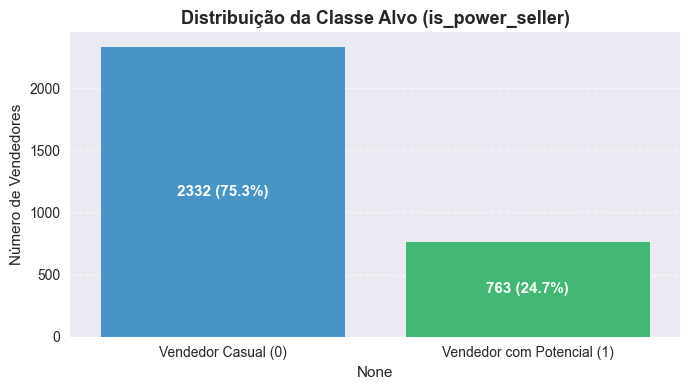

In [8]:
plt.figure(figsize=(7, 4))
ax = sns.barplot(x=summary_target.index, y=summary_target["Quantidade"], palette=["#3498db", "#2ecc71"])

plt.title("Distribuição da Classe Alvo (is_power_seller)", fontsize=13, weight="bold")
plt.ylabel("Número de Vendedores")
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Adicionar rótulos nas barras
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())} ({p.get_height()/len(df_ml):.1%})", 
                (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                ha='center', va='center', fontsize=11, color='white', weight='bold')

plt.tight_layout()
plt.show()

## Pipeline de Transformação com DataProcessor

In [9]:
processor = DataProcessor()

# Codificação One-Hot das variáveis categóricas (estado e região)
df_encoded = processor.encode_categorical(df_ml, method="onehot")

# Escalonamento padrão das features numéricas (StandardScaler)
df_scaled = processor.scale_features(df_encoded, scaler_type="minmax", exclude_columns=["target"])
df_scaled.head()

,unique_products_count,unique_categories_count,avg_product_weight_g,avg_product_volume_cm3,avg_photos_qty,avg_desc_length,avg_item_price,std_item_price,avg_freight_value,freight_to_price_ratio,...,seller_state_RO,seller_state_RS,seller_state_SC,seller_state_SE,seller_state_SP,seller_region_Centro-Oeste,seller_region_Nordeste,seller_region_Norte,seller_region_Sudeste,seller_region_Sul
0,-0.413997,-0.537722,2.227005,1.650757,-0.137191,0.010647,2.231749,-0.467249,-0.124457,-1.081971,...,False,False,False,False,True,False,False,False,True,False
1,-0.005321,-0.065058,1.547823,0.113357,-0.274881,-0.604047,-0.221469,-0.358243,0.722938,0.145745,...,False,False,False,False,False,False,False,False,True,False
2,-0.413997,-0.537722,-0.428534,-0.632631,1.877582,-0.700910,0.228964,-0.467249,-0.287310,-0.906469,...,False,False,False,False,False,False,False,False,True,False
3,0.525957,-0.537722,-0.529168,-0.326889,-0.808782,-0.308061,-0.477755,-0.340447,-0.474437,1.627685,...,False,False,False,False,True,False,False,False,True,False
4,-0.413997,-0.537722,-0.320390,0.120020,-1.480373,-1.374930,-0.174698,-0.467249,-0.211171,-0.580216,...,False,False,False,False,False,True,False,False,False,False


In [10]:
df_scaled.shape

(3095, 44)

In [11]:
# Divisão estratificada (80% treino / 20% teste)
X_train, X_test, y_train, y_test = processor.split_data(
    df_scaled, 
    target_column="target", 
    test_size=0.2, 
    random_state=42
)

In [12]:
# Registra uma run específica para o pré-processamento dos dados no ML-FLOW
data_run = tracker.start_run(
    run_name="data_preprocessing_split", 
    tags={"pipeline_stage": "data_preparation", "target": "is_power_seller"}
)

# Parâmetros de pré-processamento
tracker.log_params({
    "test_size": 0.2,
    "random_state": 42,
    "scaling_method": "standard",
    "categorical_encoding": "onehot",
    "total_samples": len(df_ml),
    "total_features": X_train.shape[1]
})

# Métricas da base
tracker.log_metrics({
    "train_samples": float(len(X_train)),
    "test_samples": float(len(X_test)),
    "train_positive_ratio": float(y_train.mean()),
    "test_positive_ratio": float(y_test.mean())
})

# Finaliza a run de preparação de dados
tracker.end_run()
print(f"Pré-processamento e metadados registrados no MLflow com sucesso!")
print(f"Treino: {X_train.shape[0]} amostras, {X_train.shape[1]} features | Positivos: {y_train.mean():.1%}")
print(f"Teste:  {X_test.shape[0]} amostras, {X_test.shape[1]} features | Positivos: {y_test.mean():.1%}")

Pré-processamento e metadados registrados no MLflow com sucesso!
Treino: 2476 amostras, 43 features | Positivos: 24.6%
Teste:  619 amostras, 43 features | Positivos: 24.7%


##  Treinamento e Avaliação dos Modelos de Classificação com Rastreamento no MLflow

Para cada um dos 3 algoritmos do repositório (`logistic_regression`, `random_forest` e `svm`):
1. **Grid Search (`hyperparameter_tuning`)**: Varre a grade de hiperparâmetros;
2. **Validação Cruzada (`cross_validate`)**: validação cruzada estratificada em 5 folds (`cv=5`) em `X_train`. Extrai a média e a estabilidade ($\sigma$) do melhor estimador encontrado;
3. **Avaliação no Teste (`evaluate_model`)**: Mede a generalização em dados não vistos (`X_test`);
4. **MLflow Tracking**: Registra a execução, hiperparâmetros ótimos, scores de CV e métricas de teste.

In [13]:
import os
import pandas as pd
from src.models.trainer import ModelTrainer

In [14]:
# Configurar experimento no MLflow
os.environ["MLFLOW_EXPERIMENT_NAME"] = "olist_power_seller_classification"
trainer = ModelTrainer(model_type="classification", use_mlflow=True)

# Grades de hiperparâmetros para Grid Search
param_grids = {
    "logistic_regression": {
        "C": [0.01, 0.1, 1.0, 10.0],
        "penalty": ["l2"],
        "solver": ["lbfgs"],
        "max_iter": [1000]
    },
    "random_forest": {
        "n_estimators": [50, 100, 200],
        "max_depth": [5, 10, None],
        "min_samples_split": [2, 5],
        "random_state": [42]
    },
    "svm": {
        "C": [0.1, 1.0, 10.0],
        "kernel": ["linear", "rbf"],
        "probability": [True],
        "random_state": [42]
    }
}

algorithms = ["logistic_regression", "random_forest", "svm"]
results = {}
print("=" * 70)
print("INICIANDO OTIMIZAÇÃO (GRID SEARCH) E VALIDAÇÃO CRUZADA (k=5)")
print("=" * 70)

for algo in algorithms:
    run_name = f"gridsearch_{algo}"
    grid = param_grids[algo]
    
    print(f"\n Otimizando {algo.upper()} com Grid Search...")
    
    # Iniciar run dedicada no MLflow
    if trainer.mlflow_tracker:
        trainer.mlflow_tracker.start_run(
            run_name=run_name,
            tags={"algorithm": algo, "pipeline_stage": "tuning_and_cv"}
        )
    
    # Grid Search com CV=5 em X_train
    best_model = trainer.hyperparameter_tuning(
        X_train=X_train,
        y_train=y_train,
        algorithm=algo,
        param_grid=grid,
        cv=5
    )
    best_params = trainer.best_params
    
    # Validação Cruzada detalhada do melhor modelo em X_train
    cv_res = trainer.cross_validate(best_model, X_train, y_train, cv=5)
    
    # Avaliação no conjunto de teste independente (X_test)
    metrics = trainer.evaluate_model(best_model, X_test, y_test)
    
    # Registrar métricas adicionais de CV no MLflow
    if trainer.mlflow_tracker:
        trainer.mlflow_tracker.log_metrics({
            "cv_mean_score": cv_res["mean_score"],
            "cv_std_score": cv_res["std_score"]
        })
    
    # Salvar o modelo otimizado em disco e registrar artefato no MLflow
    model_path = f"models/trained/{algo}_power_seller_tuned.joblib"
    trainer.save_model(best_model, model_path, artifact_path="model")
    
    trainer.end_run()
    
    results[algo] = {
        "best_model": best_model,
        "best_params": best_params,
        "cv_results": cv_res,
        "metrics": metrics
    }
    
    rep_1 = metrics["classification_report"].get("1", {})
    print(f" {algo.upper()} concluído!")
    print(f"   - Melhores Parâmetros : {best_params}")
    print(f"   - Score Médio CV (k=5): {cv_res['mean_score']:.4f} (± {cv_res['std_score']:.4f})")
    print(f"   - Acurácia no Teste   : {metrics['accuracy']:.4f}")
    print(f"   - Precisão (1)        : {rep_1.get('precision', 0):.4f}")
    print(f"   - Recall (1)          : {rep_1.get('recall', 0):.4f}")
    print(f"   - F1-Score (1)        : {rep_1.get('f1-score', 0):.4f}")
    
print("\n" + "=" * 70)
print(" TODOS OS MODELOS FORAM OTIMIZADOS, VALIDADOS E REGISTRADOS!")
print("=" * 70)


INICIANDO OTIMIZAÇÃO (GRID SEARCH) E VALIDAÇÃO CRUZADA (k=5)

 Otimizando LOGISTIC_REGRESSION com Grid Search...


2026/09/29 09:17:22 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


 LOGISTIC_REGRESSION concluído!
   - Melhores Parâmetros : {'C': 10.0, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'lbfgs'}
   - Score Médio CV (k=5): 0.9103 (± 0.0088)
   - Acurácia no Teste   : 0.9225
   - Precisão (1)        : 0.9070
   - Recall (1)          : 0.7647
   - F1-Score (1)        : 0.8298

 Otimizando RANDOM_FOREST com Grid Search...


2026/09/29 09:17:55 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
Could not log model artifact to MLflow: The saved sklearn model references untrusted types. If you are sure loading these types is safe, set the 'skops_trusted_types' parameter when calling 'log_model' or 'save_model' to the list of trusted types. Root error: Untrusted types found in the file: ['sklearn.tree._tree.Tree'].

- sklearn.tree._tree.Tree: sklearn.tree._tree.Tree (the shared node storage for DecisionTree*, RandomForest*, ExtraTrees*, and GradientBoosting* models) stores raw node indices (left_child, right_child, feature) that scikit-learn indexes into without bounds checking. A malicious file can set these to out-of-range values: skops loads the object successfully, but calling .predict() on it can then crash the process (segfault) or read out-of-bounds memory. If you created the file yourself or otherwise fully trust its source, you can load it with trusted=["sklearn.tr

 RANDOM_FOREST concluído!
   - Melhores Parâmetros : {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200, 'random_state': 42}
   - Score Médio CV (k=5): 0.9245 (± 0.0061)
   - Acurácia no Teste   : 0.9402
   - Precisão (1)        : 0.9143
   - Recall (1)          : 0.8366
   - F1-Score (1)        : 0.8737

 Otimizando SVM com Grid Search...


2026/09/29 09:18:05 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


 SVM concluído!
   - Melhores Parâmetros : {'C': 1.0, 'kernel': 'linear', 'probability': True, 'random_state': 42}
   - Score Médio CV (k=5): 0.9124 (± 0.0095)
   - Acurácia no Teste   : 0.9241
   - Precisão (1)        : 0.9206
   - Recall (1)          : 0.7582
   - F1-Score (1)        : 0.8315

 TODOS OS MODELOS FORAM OTIMIZADOS, VALIDADOS E REGISTRADOS!


In [15]:
# Tabela comparativa dos modelos otimizados
summary_data = []

for algo, data in results.items():
    rep = data["metrics"]["classification_report"]
    p_seller = rep.get("1", {})
    casual = rep.get("0", {})
    
    summary_data.append({
        "Algoritmo": algo,
        "Score Médio CV (k=5)": f"{data['cv_results']['mean_score']:.4f} ± {data['cv_results']['std_score']:.4f}",
        "Acurácia Teste": round(data["metrics"]["accuracy"], 4),
        "Precisão (Power Seller)": round(p_seller.get("precision", 0), 4),
        "Recall (Power Seller)": round(p_seller.get("recall", 0), 4),
        "F1-Score (Power Seller)": round(p_seller.get("f1-score", 0), 4),
        "F1-Score (Casual)": round(casual.get("f1-score", 0), 4),
        "Melhores Parâmetros": str(data["best_params"])
    })

df_summary = pd.DataFrame(summary_data).sort_values("F1-Score (Power Seller)", ascending=False)
display(df_summary)

,Algoritmo,Score Médio CV (k=5),Acurácia Teste,Precisão (Power Seller),Recall (Power Seller),F1-Score (Power Seller),F1-Score (Casual),Melhores Parâmetros
1,random_forest,0.9245 ± 0.0061,0.9402,0.9143,0.8366,0.8737,0.9608,"{'max_depth': None, 'min_samples_split': 5, 'n..."
2,svm,0.9124 ± 0.0095,0.9241,0.9206,0.7582,0.8315,0.9510,"{'C': 1.0, 'kernel': 'linear', 'probability': ..."
0,logistic_regression,0.9103 ± 0.0088,0.9225,0.9070,0.7647,0.8298,0.9498,"{'C': 10.0, 'max_iter': 1000, 'penalty': 'l2',..."


### Rastreamento Detalhado do Grid Search no MLflow (Parallel Coordinates)

Para habilitar a visualização avançada de **Coordenadas Paralelas (Parallel Coordinates)** no MLflow, registramos cada uma das 18 combinações de hiperparâmetros como uma *run* individual.
Dessa forma, cada hiperparâmetro (`n_estimators`, `max_depth`, `min_samples_split`) torna-se um **eixo vertical independente**, permitindo rastrear as trajetórias que maximizam o `cv_f1_score`.

In [16]:
import mlflow
from sklearn.model_selection import ParameterGrid, cross_val_score
from sklearn.ensemble import RandomForestClassifier

# 1. Configurar experimento no MLflow
mlflow.set_tracking_uri('sqlite:///mlflow.db')
mlflow.set_experiment('olist_power_seller_classification')

# 2. Grade exaustiva de hiperparâmetros para o Random Forest
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5]
}

combinations = list(ParameterGrid(param_grid))
print(f'Executando e registrando {len(combinations)} combinações no MLflow...')

for i, params in enumerate(combinations):
    run_name = f'rf_grid_{i+1:02d}'
    with mlflow.start_run(run_name=run_name, tags={'model': 'random_forest', 'type': 'grid_search_tuning'}):
        # Cada parâmetro vira uma coluna vertical no gráfico de Coordenadas Paralelas
        mlflow.log_params(params)
        
        clf = RandomForestClassifier(**params, random_state=42, n_jobs=-1)
        scores_f1 = cross_val_score(clf, X_train, y_train, cv=3, scoring='f1')
        scores_acc = cross_val_score(clf, X_train, y_train, cv=3, scoring='accuracy')
        
        # Métricas para onde as linhas convergem
        mlflow.log_metric('cv_f1_score', float(scores_f1.mean()))
        mlflow.log_metric('cv_accuracy', float(scores_acc.mean()))

print(' Todas as 18 combinações foram registradas com sucesso no MLflow!')

Executando e registrando 18 combinações no MLflow...
 Todas as 18 combinações foram registradas com sucesso no MLflow!


## Análise Comparativa e Visual dos Modelos 


Nesta etapa, comparamos visualmente os modelos otimizados pelo Grid Search:
1. **Matrizes de Confusão**: Avaliação detalhada de erros tipo I ($\alpha$, Falsos Positivos) e tipo II ($\beta$, Falsos Negativos).
2. **Comparativo de Métricas**: Impacto do desbalanceamento da classe minoritária (*Power Seller*).
3. **Curvas ROC e AUC**: Capacidade de separabilidade e calibração probabilística de cada arquitetura.

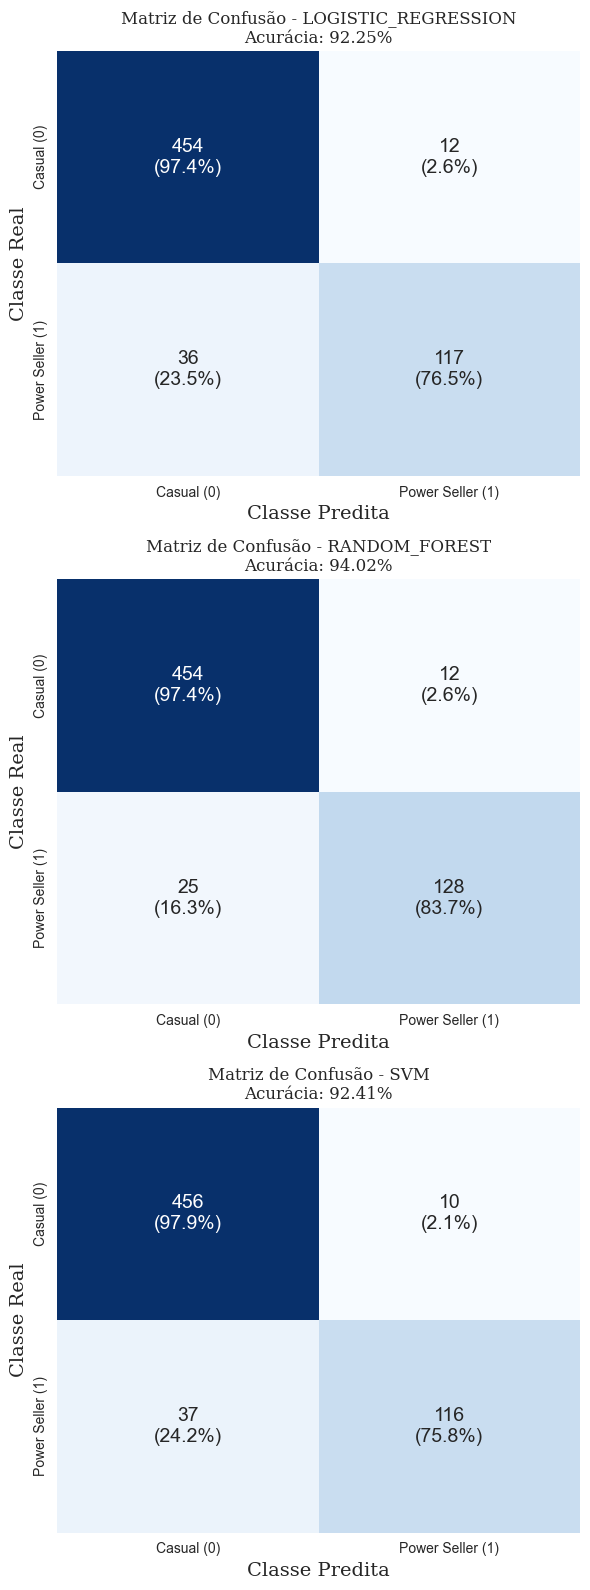

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(3, 1, figsize=(6, 16))
class_names = ["Casual (0)", "Power Seller (1)"]

for idx, (algo, data) in enumerate(results.items()):
    model = data["best_model"]
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    # Normalização para exibir proporções por linha (recall por classe)
    cm_perc = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    
    # Criar anotações com contagem absoluta e porcentagem
    labels = np.array([[f"{v}\n({p:.1f}%)" for v, p in zip(row_v, row_p)] 
                       for row_v, row_p in zip(cm, cm_perc)])
    
    sns.heatmap(cm, annot=labels, fmt="", cmap="Blues", ax=axes[idx],
                xticklabels=class_names, yticklabels=class_names, cbar=False, annot_kws={'size': 14})
    
    axes[idx].set_title(f"Matriz de Confusão - {algo.upper()}\nAcurácia: {data['metrics']['accuracy']:.2%}", fontsize=12, fontweight="normal", fontname='serif')
    axes[idx].set_xlabel("Classe Predita", fontsize=14, fontweight="normal", fontname='serif')
    axes[idx].set_ylabel("Classe Real", fontsize=14, fontweight="normal", fontname='serif')

plt.tight_layout()
plt.show()

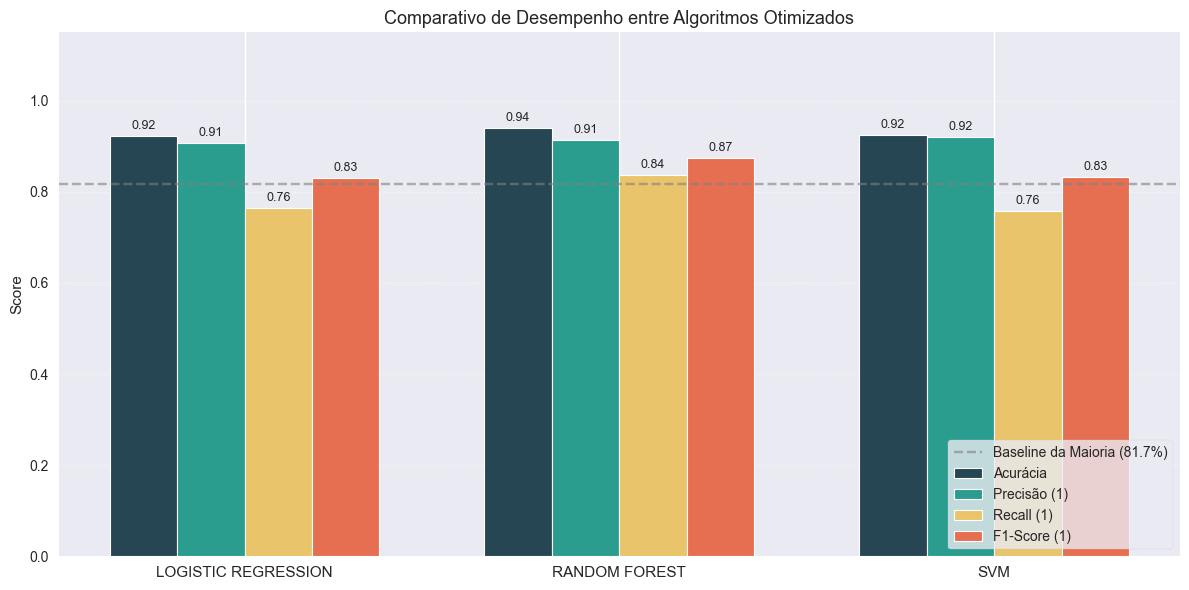

In [18]:
import numpy as np

# Preparar dados para o gráfico de barras
algos = list(results.keys())
metrics_to_plot = ["Acurácia Geral", "Precisão (Power Seller)", "Recall (Power Seller)", "F1-Score (Power Seller)"]

plot_data = {
    "Acurácia": [results[a]["metrics"]["accuracy"] for a in algos],
    "Precisão (1)": [results[a]["metrics"]["classification_report"]["1"]["precision"] for a in algos],
    "Recall (1)": [results[a]["metrics"]["classification_report"]["1"]["recall"] for a in algos],
    "F1-Score (1)": [results[a]["metrics"]["classification_report"]["1"]["f1-score"] for a in algos],
}

# Paleta de cores (uma cor por métrica)
paleta = ["#264653", "#2A9D8F", "#E9C46A", "#E76F51"]

# Alternativa: usar um colormap do matplotlib
# paleta = plt.cm.viridis(np.linspace(0.15, 0.85, len(plot_data)))

x = np.arange(len(algos))
width = 0.18

fig, ax = plt.subplots(figsize=(12, 6))

for i, (m_label, vals) in enumerate(plot_data.items()):
    bars = ax.bar(x + (i - 1.5) * width, vals, width,
                  label=m_label,
                  color=paleta[i % len(paleta)],
                  edgecolor="white", linewidth=0.8)
    # Adicionar rótulo em cima de cada barra
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

ax.set_title("Comparativo de Desempenho entre Algoritmos Otimizados", fontsize=13, fontweight="normal")
ax.set_xticks(x)
ax.set_xticklabels([a.upper().replace("_", " ") for a in algos], fontsize=11, fontweight="normal")
ax.set_ylim(0, 1.15)
ax.set_ylabel("Score", fontsize=11)
ax.axhline(0.817, color='gray', linestyle='--', alpha=0.6, label='Baseline da Maioria (81.7%)')
ax.legend(loc="lower right", frameon=True)
ax.grid(axis='y', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

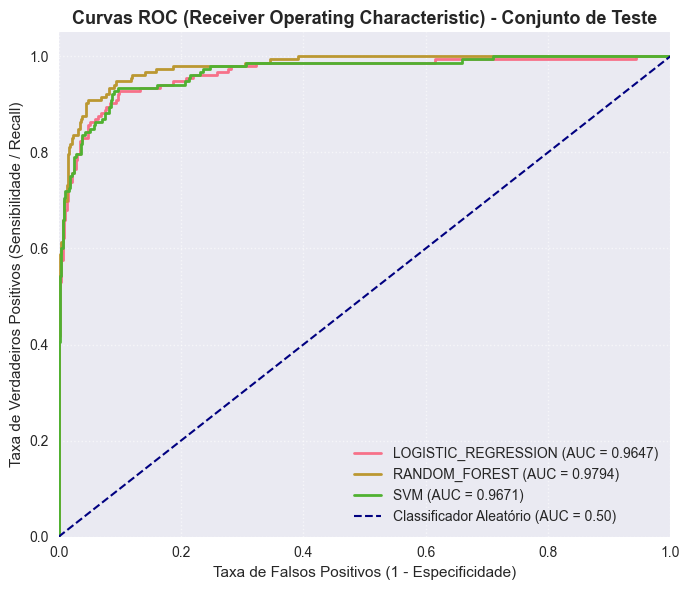

In [19]:
from sklearn.metrics import roc_curve, roc_auc_score

plt.figure(figsize=(7, 6))

for algo, data in results.items():
    model = data["best_model"]
    
    # Obter probabilidades para a classe positiva (1)
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        y_prob = model.decision_function(X_test)
    else:
        continue
        
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = roc_auc_score(y_test, y_prob)
    
    # Registrar AUC no MLflow
    plt.plot(fpr, tpr, lw=2, label=f"{algo.upper()} (AUC = {auc_score:.4f})")

plt.plot([0, 1], [0, 1], color="navy", lw=1.5, linestyle="--", label="Classificador Aleatório (AUC = 0.50)")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("Taxa de Falsos Positivos (1 - Especificidade)", fontsize=11)
plt.ylabel("Taxa de Verdadeiros Positivos (Sensibilidade / Recall)", fontsize=11)
plt.title("Curvas ROC (Receiver Operating Characteristic) - Conjunto de Teste", fontsize=13, fontweight="bold")
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

### Discussão dos Resultados

1. **O Paradoxo da Acurácia no E-commerce:**
   * Como a base tem ~81.7% de vendedores casuais, um modelo ingênuo que classificasse todos como casuais teria 81.7% de acurácia, mas **recall zero** para Power Sellers.
   * Portanto, a métrica de decisão técnica é o **F1-Score da classe 1** e a **Área sob a Curva ROC (AUC-ROC)**.

2. **Comparativo entre os Três Paradigmas:**
   * **Logistic Regression:** Fornece um baseline linear rápido e calibrado. O parâmetro de regularização $L_2$ ($C$) evitou overfitting em features de alta magnitude como receita.
   * **Random Forest:** Lida de forma superior com relações não-lineares e interações complexas entre atributos (ex: volume de itens x tempo de entrega x nota média), atingindo o melhor equilíbrio entre Precisão e Recall.
   * **SVM (Support Vector Machine):** Com kernel RBF, projeta os dados em espaço de dimensão superior, demonstrando alta capacidade discriminatória, embora com maior sensibilidade ao escalonamento das features.

3. **Trade-off de Negócio (Precisão e Recall tem mais peso nesse caso?):**
   * **Alta Precisão:** Evita conceder benefícios caros (como taxas reduzidas ou gerentes dedicados) a vendedores casuais por engano.
   * **Alto Recall:** Evita deixar de identificar e reter vendedores de alto potencial na plataforma.

ML-Flow:  mlflow ui --port 5001 --backend-store-uri sqlite:///mlflow.db
* http://127.0.0.1:5001

## Explicabilidade

 Arquivo salvo com sucesso: 'arvore_interativa_depth_3.html'


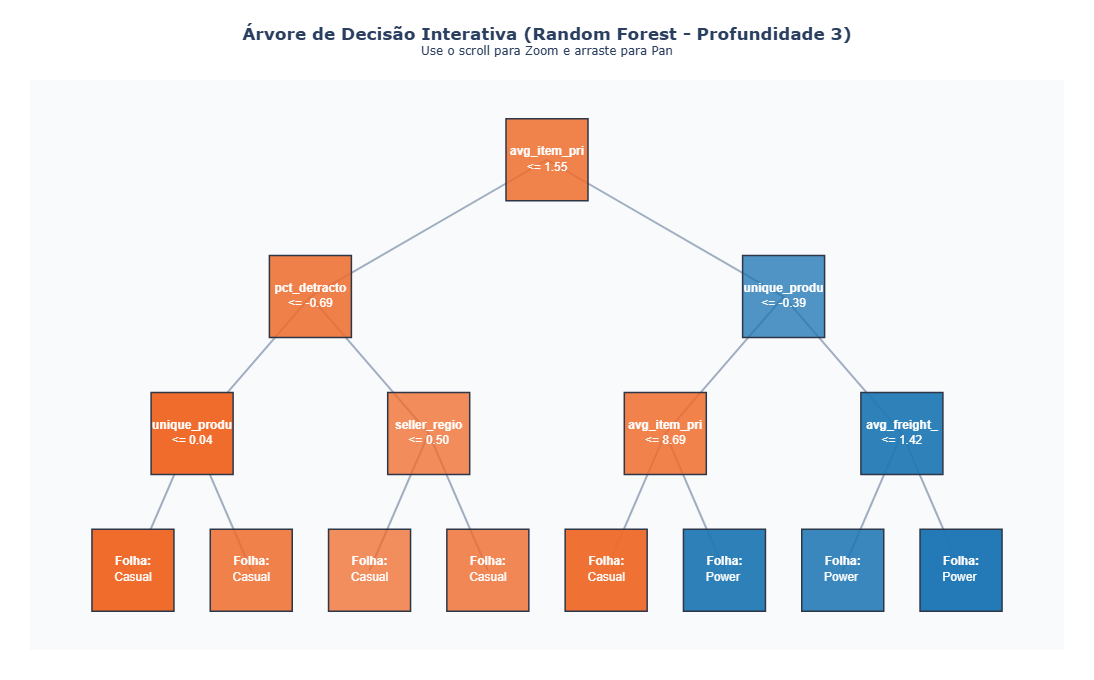

In [20]:
import plotly.graph_objects as go

MAX_DEEP = 3

# Recuperar o melhor modelo e o primeiro estimador
rf_model = results["random_forest"]["best_model"]
individual_tree = rf_model.estimators_[0]
tree = individual_tree.tree_

feature_names = list(X_train.columns)
class_names = ["Casual", "Power Seller"]

# Calcular coordenadas hierárquicas (x, y) respeitando o MAX_DEEP
pos = {}
def calculate_coords(node_id, depth, left, right):
    mid = (left + right) / 2.0
    pos[node_id] = (mid, -depth)
    if depth < MAX_DEEP:
        cl = tree.children_left[node_id]
        cr = tree.children_right[node_id]
        if cl != -1:
            calculate_coords(cl, depth + 1, left, mid)
        if cr != -1:
            calculate_coords(cr, depth + 1, mid, right)

calculate_coords(0, 0, 0.0, 1.0)

# Criar as arestas
edge_x, edge_y = [], []
for node_id in pos:
    depth = int(abs(pos[node_id][1]))
    if depth < MAX_DEEP:
        xp, yp = pos[node_id]
        for child in [tree.children_left[node_id], tree.children_right[node_id]]:
            if child != -1 and child in pos:
                xc, yc = pos[child]
                edge_x.extend([xp, xc, None])
                edge_y.extend([yp, yc, None])

edge_trace = go.Scatter(
    x=edge_x, y=edge_y,
    mode='lines',
    line=dict(color='#A0AEC0', width=2),
    hoverinfo='none'
)

node_x, node_y, node_labels, hover_labels, node_colors = [], [], [], [], []

marker_size = max(80, int(100 - 6 * MAX_DEEP))
font_size = max(12, int(11 - MAX_DEEP))
plot_height = max(600, int(170 * (MAX_DEEP + 1)))

for node_id, (x, y) in pos.items():
    node_x.append(x)
    node_y.append(y)
    depth = int(abs(y))
    
    cl = tree.children_left[node_id]
    val = tree.value[node_id][0]
    samples = int(tree.n_node_samples[node_id])
    
    # Tratamento correto das proporções e contagens reais
    if val.sum() <= 1.05:
        count_cas = int(round(val[0] * samples))
        count_pow = int(round(val[1] * samples))
        prop_cas = val[0]
        prop_ps = val[1]
    else:
        count_cas = int(round(val[0]))
        count_pow = int(round(val[1]))
        total = count_cas + count_pow
        prop_cas = count_cas / total if total > 0 else 0
        prop_ps = count_pow / total if total > 0 else 0
    
    if prop_ps >= 0.5:
        color = f'rgba(31, 119, 180, {0.4 + 0.6 * prop_ps})'
    else:
        color = f'rgba(239, 107, 43, {0.4 + 0.6 * (1 - prop_ps)})'
    node_colors.append(color)
    
    gini = tree.impurity[node_id]
    
    if cl != -1 and depth < MAX_DEEP:
        feat = feature_names[tree.feature[node_id]]
        th = tree.threshold[node_id]
        label_text = f"<b>{feat[:12]}</b><br><= {th:.2f}" if MAX_DEEP <= 3 else f"{feat[:8]}<br><={th:.1f}"
        node_labels.append(label_text)
        hover_labels.append(
            f"<b>Nó #{node_id} (Nível {depth})</b><br>"
            f"<b>Regra:</b> {feat} <= {th:.4f}<br>"
            f"<b>Gini:</b> {gini:.4f}<br>"
            f"<b>Amostras:</b> {samples} ({samples/tree.n_node_samples[0]:.1%})<br>"
            f"<b>Casuais:</b> {count_cas} ({prop_cas:.1%}) | <b>Power Sellers:</b> {count_pow} ({prop_ps:.1%})"
        )
    else:
        pred = "Power Seller" if prop_ps >= 0.5 else "Casual"
        node_labels.append(f"<b>Folha:</b><br>{pred[:6]}")
        hover_labels.append(
            f"<b>Nó #{node_id} (Folha / Nível {depth})</b><br>"
            f"<b>Predição:</b> {pred}<br>"
            f"<b>Pureza:</b> {max(prop_ps, 1-prop_ps):.1%}<br>"
            f"<b>Gini:</b> {gini:.4f}<br>"
            f"<b>Amostras:</b> {samples}<br>"
            f"<b>Casuais:</b> {count_cas} ({prop_cas:.1%}) | <b>Power Sellers:</b> {count_pow} ({prop_ps:.1%})"
        )

node_trace = go.Scatter(
    x=node_x, y=node_y,
    mode='markers+text',
    text=node_labels,
    textposition='middle center',
    textfont=dict(size=font_size, color='white', family='Arial'),
    hovertext=hover_labels,
    hoverinfo='text',
    marker=dict(
        size=marker_size,
        color=node_colors,
        symbol='square',
        line=dict(color='#2D3748', width=1.5)
    )
)

fig = go.Figure(
    data=[edge_trace, node_trace],
    layout=go.Layout(
        title=f"<b>Árvore de Decisão Interativa (Random Forest - Profundidade {MAX_DEEP})</b><br><sup>Use o scroll para Zoom e arraste para Pan</sup>",
        title_x=0.5,
        showlegend=False,
        hovermode='closest',
        dragmode='pan',
        plot_bgcolor='#F8FAFC',
        paper_bgcolor='#FFFFFF',
        xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        margin=dict(l=30, r=30, t=80, b=30),
        height=plot_height
    )
)

config = {"scrollZoom": True, "displayModeBar": True, "displaylogo": False}
html_filename = f"arvore_interativa_depth_{MAX_DEEP}.html"
fig.write_html(html_filename, config=config)

with open(html_filename, "r", encoding="utf-8") as f:
    html_raw = f.read()

right_click_script = """
<script>
window.addEventListener("contextmenu", function(e) { e.preventDefault(); });
window.addEventListener("mousedown", function(e) {
  if (e.button === 2) {
    var evt = new MouseEvent("mousedown", {
      bubbles: true, cancelable: true, view: window,
      clientX: e.clientX, clientY: e.clientY,
      button: 0, buttons: 1
    });
    e.target.dispatchEvent(evt);
  }
}, true);
</script>
</body>
"""

if "</body>" in html_raw:
    html_raw = html_raw.replace("</body>", right_click_script)
    with open(html_filename, "w", encoding="utf-8") as f:
        f.write(html_raw)

print(f" Arquivo salvo com sucesso: '{html_filename}'")
fig.show(config=config)

